In [1]:
!pip install -q transformers accelerate pillow datasets

In [2]:
import torch
import numpy as np
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText

print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
import torch
import numpy as np
from PIL import Image
from datasets import load_dataset
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from tqdm import tqdm

# Load model
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(model_id)

# Load dataset
dataset = load_dataset("anvo25/vlms-are-biased", split="main")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

Generating identification split:   0%|          | 0/1392 [00:00<?, ? examples/s]

Generating withtitle split:   0%|          | 0/2784 [00:00<?, ? examples/s]

Generating original split:   0%|          | 0/458 [00:00<?, ? examples/s]

Generating remove_background_q1q2 split:   0%|          | 0/2784 [00:00<?, ? examples/s]

Generating remove_background_q3 split:   0%|          | 0/1392 [00:00<?, ? examples/s]

In [ ]:
from collections import Counter

def is_single_token(val):
    ids = processor.tokenizer.encode(str(val), add_special_tokens=False)
    return len(ids) == 1


# 1. Exclude optical illusions (watch spelling carefully)
dataset = dataset.filter(lambda x: x['topic'] != 'Optical Illusion')


# 2. Keep only single-token GT + bias
dataset = dataset.filter(
    lambda x: is_single_token(x['ground_truth']) and is_single_token(x['expected_bias'])
)

dataset = dataset.add_column("idx", list(range(len(dataset))))
torch.save(dataset["idx"], "qwen_indices.pt")

# 3. Sanity check distribution
topic_counts = Counter(dataset['topic'])
for topic, count in topic_counts.items():
    print(f"{topic}: {count}")

print(f"\nTotal: {len(dataset)}")

Filter:   0%|          | 0/2784 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1992 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1674 [00:00<?, ? examples/s]

Game Boards: 84
Patterned Grid: 336
Chess Pieces: 138
Logos: 414
Flags: 156
Animals: 546

Total: 1674


In [ ]:
import re
import torch

def run_with_logprobs(image, prompt):
    prompt = prompt + "\nAnswer with exactly ONE digit (0-9). No text, no multiple digits."
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt").to("cuda")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True
        )

    scores = torch.stack(output.scores, dim=0).squeeze(1)  # (T, vocab)
    log_probs = torch.log_softmax(scores, dim=-1)

    response = processor.tokenizer.decode(output.sequences[0], skip_special_tokens=True)
    answer = response.split("assistant")[-1].strip()

    return answer, log_probs, output.sequences[0], inputs


def get_answer_token_id(text):
    ids1 = processor.tokenizer.encode(str(text), add_special_tokens=False)
    ids2 = processor.tokenizer.encode(" " + str(text), add_special_tokens=False)

    if len(ids1) == 1:
        return ids1[0]
    elif len(ids2) == 1:
        return ids2[0]
    else:
        print(f"Skipping non-single-token: {text} -> {ids1} / {ids2}")
        return None


def analyze_sample(sample):
    gt = str(sample['ground_truth'])
    bias = str(sample['expected_bias'])

    gt_token_id = get_answer_token_id(gt)
    bias_token_id = get_answer_token_id(bias)

    answer, log_probs, tokens, inputs = run_with_logprobs(
        sample['image'],
        sample['prompt']
    )

    gen_tokens = tokens[inputs['input_ids'].shape[1]:]

    answer_step = None
    detected_digit = None

    for i, tok_id in enumerate(gen_tokens):
        tok_str = processor.tokenizer.decode([tok_id]).strip()

        if tok_str.isdigit() and len(tok_str) == 1:
            answer_step = i
            detected_digit = tok_str
            break

    margin, entropy = None, None

    if answer_step is not None:

        lp = log_probs[answer_step]

        margin = (lp[gt_token_id] - lp[bias_token_id]).item()
        entropy = -(lp.exp() * lp).sum().item()

    return {
        "topic": sample['topic'],
        "question_type": sample['type_of_question'],
        "ground_truth": gt,
        "expected_bias": bias,
        "model_answer": answer,
        "detected_digit": detected_digit,
        "answer_step": answer_step,
        "correct": str(detected_digit) == str(gt),
        "margin": margin,
        "entropy": entropy

    }

In [ ]:
from tqdm import tqdm

def run_batch(dataset, max_samples=None):
    results = []

    data = dataset if max_samples is None else dataset.select(range(max_samples))

    for sample in tqdm(data):
        try:
            r = analyze_sample(sample)
            if r is not None:
                results.append(r)
        except Exception:
            continue

    return results


results = run_batch(dataset)
print(f"Collected {len(results)}")

100%|██████████| 1674/1674 [28:01<00:00,  1.00s/it]

Collected 1674


In [ ]:
import pandas as pd

df = pd.DataFrame(results)

df.to_parquet("qwen_phase1_3B.parquet", index=False)

In [ ]:
df_clean = df.dropna(subset=["answer_step", "margin", "entropy"])

print("Usable samples:", len(df_clean))

Usable samples: 1672


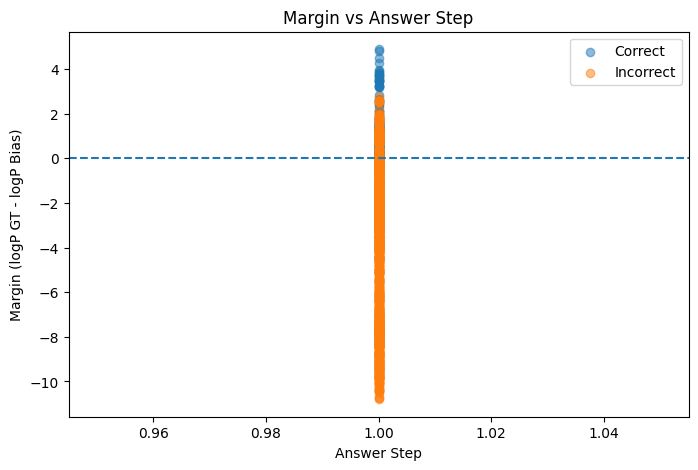

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for correct_val, label in [(True, "Correct"), (False, "Incorrect")]:
    subset = df_clean[df_clean["correct"] == correct_val]
    plt.scatter(subset["answer_step"], subset["margin"], alpha=0.5, label=label)

plt.axhline(0, linestyle="--")
plt.xlabel("Answer Step")
plt.ylabel("Margin (logP GT - logP Bias)")
plt.title("Margin vs Answer Step")
plt.legend()
plt.show()

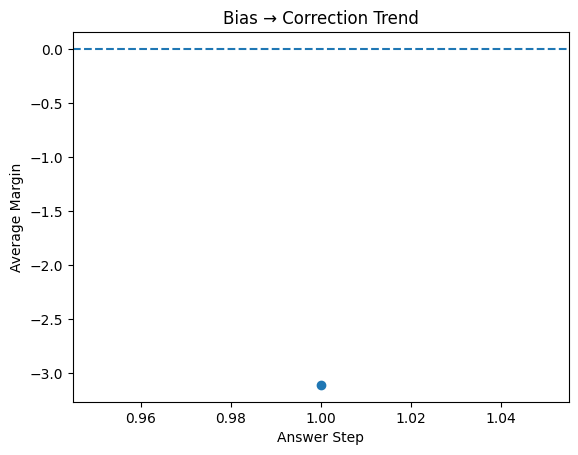

In [ ]:
df_clean.groupby("answer_step")["margin"].mean().plot(marker="o")

plt.axhline(0, linestyle="--")
plt.xlabel("Answer Step")
plt.ylabel("Average Margin")
plt.title("Bias → Correction Trend")
plt.show()

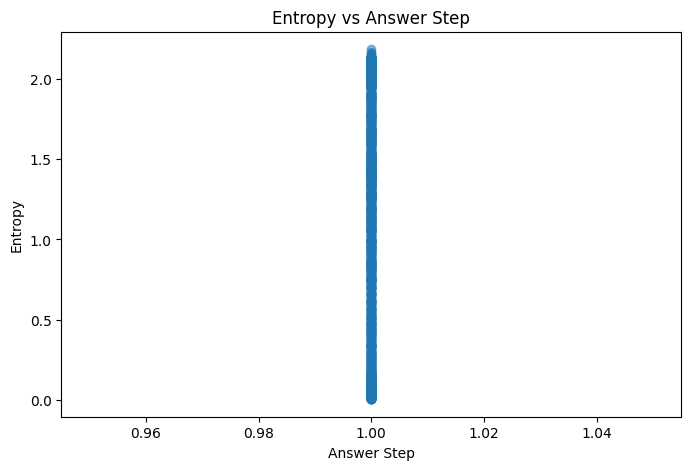

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df_clean["answer_step"], df_clean["entropy"], alpha=0.5)

plt.xlabel("Answer Step")
plt.ylabel("Entropy")
plt.title("Entropy vs Answer Step")
plt.show()

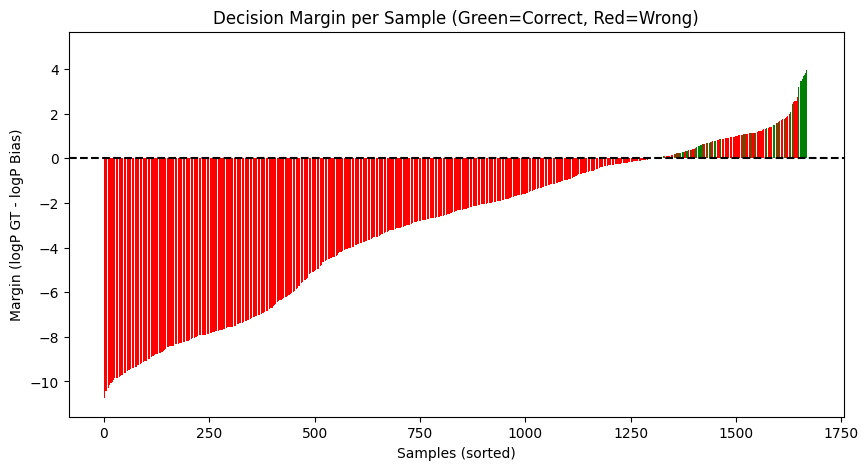

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df_sorted = df_clean.sort_values("margin")

colors = df_sorted["correct"].map({True: "green", False: "red"})

plt.bar(range(len(df_sorted)), df_sorted["margin"], color=colors)

plt.axhline(0, linestyle="--", color="black")

plt.title("Decision Margin per Sample (Green=Correct, Red=Wrong)")
plt.ylabel("Margin (logP GT - logP Bias)")
plt.xlabel("Samples (sorted)")

plt.show()

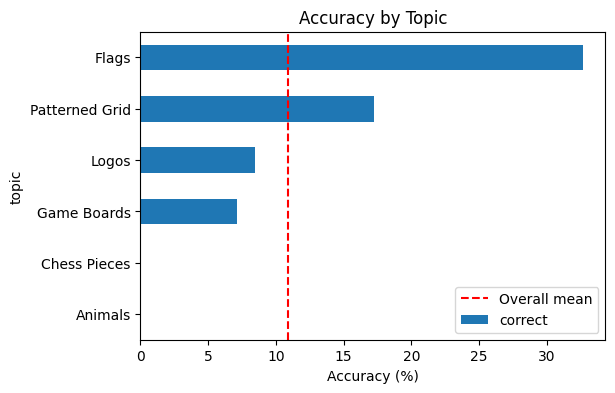

In [ ]:
topic_acc = df.groupby("topic")["correct"].mean() * 100

plt.figure(figsize=(6,4))
topic_acc.sort_values().plot(kind="barh")

plt.axvline(topic_acc.mean(), color="red", linestyle="--", label="Overall mean")

plt.xlabel("Accuracy (%)")
plt.title("Accuracy by Topic")
plt.legend()

plt.show()

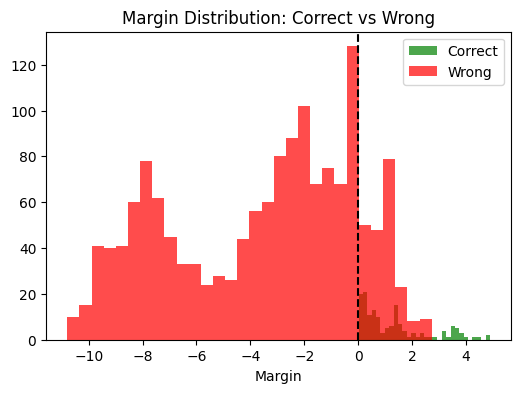

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df_clean[df_clean["correct"]]["margin"], bins=30, alpha=0.7, label="Correct", color="green")
plt.hist(df_clean[~df_clean["correct"]]["margin"], bins=30, alpha=0.7, label="Wrong", color="red")

plt.axvline(0, linestyle="--", color="black")

plt.xlabel("Margin")
plt.title("Margin Distribution: Correct vs Wrong")
plt.legend()

plt.show()

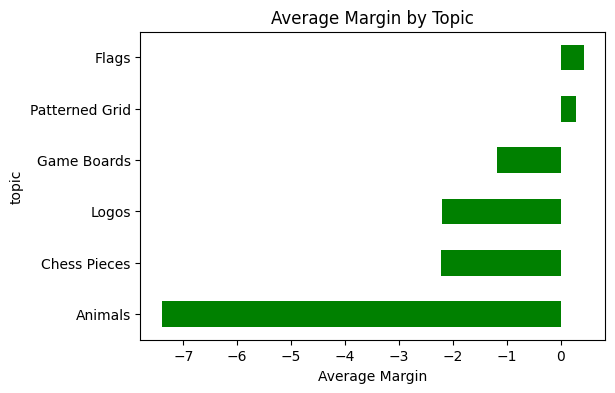

In [ ]:
topic_margin = df_clean.groupby("topic")["margin"].mean().sort_values()

plt.figure(figsize=(6,4))
topic_margin.plot(kind="barh", color="green")

plt.xlabel("Average Margin")
plt.title("Average Margin by Topic")

plt.show()

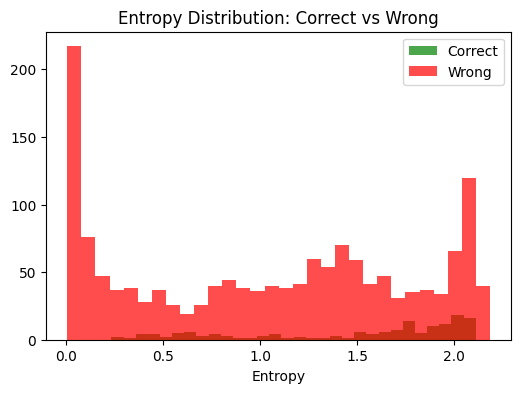

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df_clean[df_clean["correct"]]["entropy"], bins=30, alpha=0.7, label="Correct", color="green")
plt.hist(df_clean[~df_clean["correct"]]["entropy"], bins=30, alpha=0.7, label="Wrong", color="red")

plt.xlabel("Entropy")
plt.title("Entropy Distribution: Correct vs Wrong")
plt.legend()

plt.show()

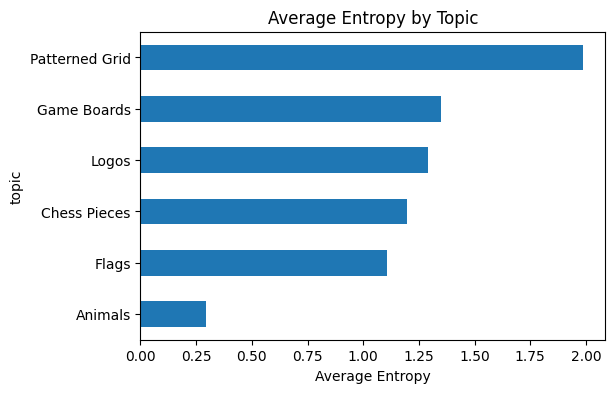

In [ ]:
topic_entropy = df_clean.groupby("topic")["entropy"].mean().sort_values()

plt.figure(figsize=(6,4))
topic_entropy.plot(kind="barh")

plt.xlabel("Average Entropy")
plt.title("Average Entropy by Topic")

plt.show()

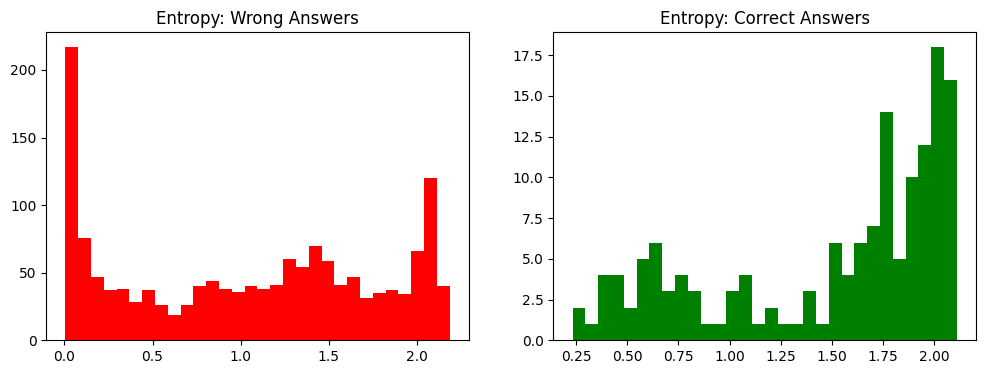

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Wrong
axes[0].hist(df_clean[~df_clean["correct"]]["entropy"], bins=30, color="red")
axes[0].set_title("Entropy: Wrong Answers")

# Correct
axes[1].hist(df_clean[df_clean["correct"]]["entropy"], bins=30, color="green")
axes[1].set_title("Entropy: Correct Answers")

plt.show()